<a href="https://colab.research.google.com/github/jainampatel3107/Fraud-Detection-in-Financial-Transactions/blob/main/Fraud%20Detection%20in%20Financial%20Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Download the dataset
!wget -O creditcard.csv https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv

print('Dataset downloaded successfully!')

--2026-06-18 12:10:49--  https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102634230 (98M) [text/plain]
Saving to: ‘creditcard.csv’

creditcard.csv      100%[===================>]  97.88M   245MB/s    in 0.4s    

2026-06-18 12:10:53 (245 MB/s) - ‘creditcard.csv’ saved [102634230/102634230]

Dataset downloaded successfully!


Dataset Shape:
(284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


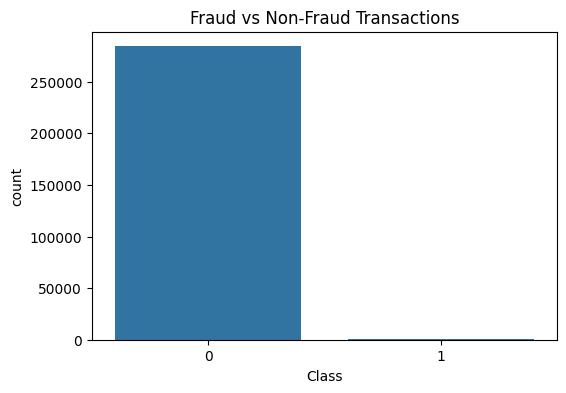


Applying SMOTE...

Balanced Dataset:
Class
0    284315
1    284315
Name: count, dtype: int64

Training Random Forest...

MODEL PERFORMANCE
Accuracy : 0.9999
Precision: 0.9997
Recall   : 1.0
F1 Score : 0.9999
ROC AUC  : 0.9999

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



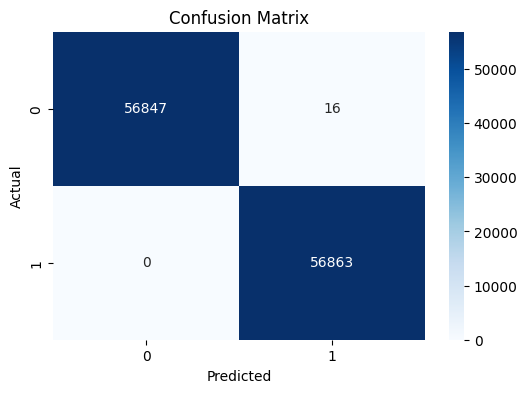


Top 10 Important Features:

   Feature  Importance
14     V14    0.188463
10     V10    0.110990
12     V12    0.100449
4       V4    0.097184
17     V17    0.088476
11     V11    0.056440
16     V16    0.055838
3       V3    0.052065
2       V2    0.038200
9       V9    0.026717


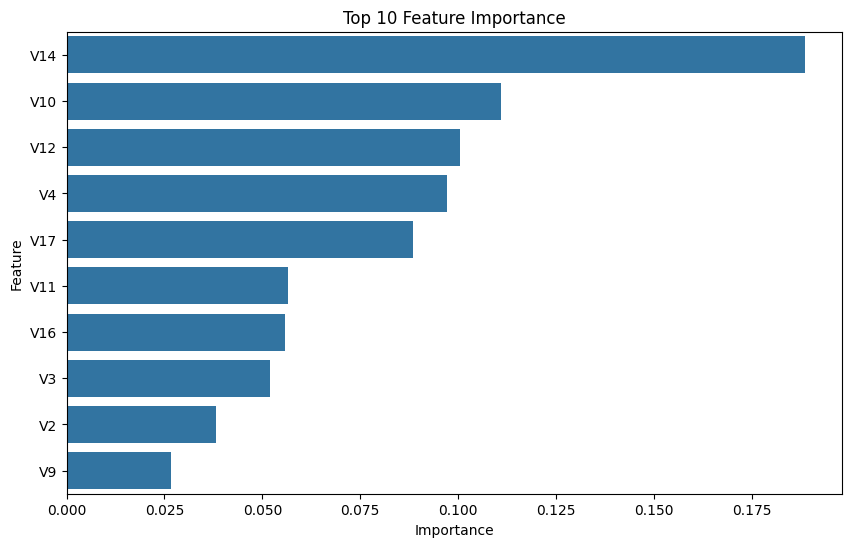


Running Isolation Forest...

Isolation Forest Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.25      0.25       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807


Generating Fraud Alerts...

    Fraud Probability Alert Level
0                1.00   HIGH RISK
1                1.00   HIGH RISK
2                0.00    LOW RISK
3                0.01    LOW RISK
4                1.00   HIGH RISK
5                0.00    LOW RISK
6                0.01    LOW RISK
7                1.00   HIGH RISK
8                0.00    LOW RISK
9                1.00   HIGH RISK
10               0.00    LOW RISK
11               1.00   HIGH RISK
12               1.00   HIGH RISK
13               0.01    LOW RISK
14               1.00   HIGH RISK
15               1.00   HIGH RISK
16       

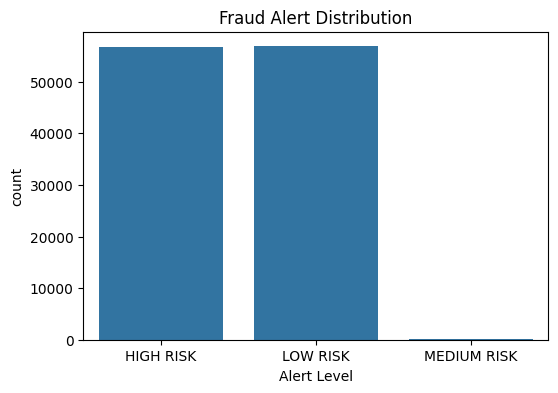


Saved:
high_risk_transactions.csv

Fraud Detection Project Completed Successfully!


In [11]:
# =====================================================
# FRAUD DETECTION IN FINANCIAL TRANSACTIONS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

# =====================================================
# 1. LOAD DATASET
# =====================================================

df = pd.read_csv("creditcard.csv", engine='python')

print("Dataset Shape:")
print(df.shape)

print("\nClass Distribution:")
print(df["Class"].value_counts())

# =====================================================
# 2. CHECK MISSING VALUES
# =====================================================

print("\nMissing Values:")
print(df.isnull().sum())

# =====================================================
# 3. FEATURE SCALING
# =====================================================

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

# =====================================================
# 4. DATA VISUALIZATION
# =====================================================

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

# =====================================================
# 5. SPLIT FEATURES & TARGET
# =====================================================

X = df.drop("Class", axis=1)
y = df["Class"]

# =====================================================
# 6. HANDLE CLASS IMBALANCE USING SMOTE
# =====================================================

print("\nApplying SMOTE...")

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nBalanced Dataset:")
print(pd.Series(y_resampled).value_counts())

# =====================================================
# 7. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

# =====================================================
# 8. RANDOM FOREST CLASSIFIER
# =====================================================

print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# =====================================================
# 9. EVALUATION
# =====================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(roc_auc,4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 10. CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 11. FEATURE IMPORTANCE
# =====================================================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:\n")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.show()

# =====================================================
# 12. ISOLATION FOREST ANOMALY DETECTION
# =====================================================

print("\nRunning Isolation Forest...")

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.0017,
    random_state=42
)

iso_model.fit(X)

iso_predictions = iso_model.predict(X)

iso_predictions = np.where(
    iso_predictions == -1,
    1,
    0
)

print("\nIsolation Forest Results:\n")

print(
    classification_report(
        y,
        iso_predictions
    )
)

# =====================================================
# 13. FRAUD ALERT SYSTEM
# =====================================================

print("\nGenerating Fraud Alerts...\n")

probabilities = rf_model.predict_proba(X_test)

fraud_probability = probabilities[:,1]

alerts = []

for prob in fraud_probability:

    if prob >= 0.90:
        alerts.append("HIGH RISK")

    elif prob >= 0.70:
        alerts.append("MEDIUM RISK")

    else:
        alerts.append("LOW RISK")

alert_df = pd.DataFrame({
    "Fraud Probability": fraud_probability,
    "Alert Level": alerts
})

print(alert_df.head(20))

# =====================================================
# 14. ALERT DISTRIBUTION
# =====================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="Alert Level",
    data=alert_df
)

plt.title("Fraud Alert Distribution")
plt.show()

# =====================================================
# 15. SAVE SUSPICIOUS TRANSACTIONS
# =====================================================

high_risk = alert_df[
    alert_df["Alert Level"] == "HIGH RISK"
]

high_risk.to_csv(
    "high_risk_transactions.csv",
    index=False
)

print("\nSaved:")
print("high_risk_transactions.csv")

# =====================================================
# END OF PROJECT
# =====================================================

print("\nFraud Detection Project Completed Successfully!")